In [3]:
import pandas as pd
from transformers import AutoTokenizer,AutoModelForSequenceClassification,AutoConfig
from vllm import LLM, SamplingParams
import torch
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt

# 0. Load Example Data
The example here is the PMC5628943 full text in nxml file. We will use bs4 to load it into dataframe. 

This example is the case study mentioned in the result section of PubMind paper.

In [6]:
def get_full_text_paragraphs(nxml):
    
    nxml_files = nxml

    if nxml_files:
        with open(nxml_files, "r", encoding="utf-8") as file:
            content = file.read()
        soup = BeautifulSoup(content, "xml")
        
        
        # Extract paragraphs
        paragraphs = []
        
        abstract_section = soup.find("abstract")
        if abstract_section:
            abstract_text = abstract_section.get_text(separator=" ", strip=True)
            #if keep_paragraph_bert(abstract_text):
            paragraphs.append({"section": "abstract", "paragraph": abstract_text})
            
        for sec in soup.find_all("sec"):
            section_title = sec.find("title").get_text(strip=True) if sec.find("title") else "No Title"

            # Skip irrelevant sections
            section_not_interest = ["method", "acknowledgment", "reference"]
            if any(sec_name in section_title.lower() for sec_name in section_not_interest):
                continue
            
            valid_sections = ["abstract", "introduction", "method", "result", "discussion", "conclusion"
                             "methods", "results", "discussions"]
            if not any(sec == section_title.lower() for sec in valid_sections):
                    section_title = "Others"
            for p in sec.find_all("p"):
                paragraph_text = p.get_text(separator=" ", strip=True)
                #if keep_paragraph_bert(paragraph_text):
                paragraphs.append({"section": section_title, "paragraph": paragraph_text})

        # Convert to DataFrame
        df = pd.DataFrame(paragraphs,columns=['section','paragraph'])
        
        unknown_section_mask = df["section"] == "Others"

        # Drop duplicates only in "Others"
        df_sort = pd.concat([
            df[~unknown_section_mask],  
            df[unknown_section_mask].drop_duplicates(subset=["paragraph"]) # make sure "Others" rank at the bottom
        ])

        df_sort = df_sort.drop_duplicates(subset=["paragraph"], keep="first").reset_index(drop=True)

        return df_sort

    return pd.DataFrame(columns=["section", "paragraph"])

In [7]:
df_input = get_full_text_paragraphs('example/PMC5628943.nxml')

In [41]:
df_input['PMCID'] = 'PMC5628943'

In [43]:
df_input=df_input[['PMCID','section','paragraph']]

In [44]:
df_input

,PMCID,section,paragraph
0,PMC5628943,abstract,Large-scale sequencing efforts have captured a...
1,PMC5628943,Introduction,The rapid development of next-generation seque...
2,PMC5628943,Introduction,One well-studied example of a common congenita...
3,PMC5628943,Introduction,The large number of human IRF6 gene variants a...
4,PMC5628943,Results,To establish a zebrafish irf6 null model and i...
5,PMC5628943,Results,(A) Zebrafish irf6 gene structure composed of ...
6,PMC5628943,Results,It has been previously reported through gene e...
7,PMC5628943,Results,The 8bp deletion in the irf6 coding region was...
8,PMC5628943,Results,Although the CRISPR gRNA used to generate the ...
9,PMC5628943,Results,(A-L) Zebrafish embryos at 96 hpf stained with...


# 1. Filtering Module (finetuned BERT)

There are 35 paragraphs extracted from the full text, but not all of them have vairant information and it will be inefficient to run LLM for all of them. Here we used a finetuned BERT model to classify each paragraph and keep only the paragraph that contains enriched variant and functional information.

In [45]:
# Load the BERT model
bert_model = AutoModelForSequenceClassification.from_pretrained("Wangwpi/PubMind_finetuned_BERT")

# Load the tokenizer
bert_tokenizer = AutoTokenizer.from_pretrained("Wangwpi/PubMind_finetuned_BERT")

# Move to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bert_model.to(device)

print("Model successfully loaded!")

Model successfully loaded!


In [46]:
# Function to run prediction using BERT
def predict(text):
    inputs = bert_tokenizer(text, truncation=True, padding="max_length", max_length=512, return_tensors="pt")
    
    # Move input tensors to the same device as the model
    inputs = {key: val.to(device) for key, val in inputs.items()}
    
    # Disable gradient calculation for inference
    with torch.no_grad():
        outputs = bert_model(**inputs)
    
    logits = outputs.logits
    prediction = torch.argmax(logits, dim=-1).item()
    return prediction


In [47]:
df_input["BERT_pred"] = df_input["paragraph"].apply(predict)
df_input

,PMCID,section,paragraph,BERT_pred
0,PMC5628943,abstract,Large-scale sequencing efforts have captured a...,1
1,PMC5628943,Introduction,The rapid development of next-generation seque...,1
2,PMC5628943,Introduction,One well-studied example of a common congenita...,1
3,PMC5628943,Introduction,The large number of human IRF6 gene variants a...,1
4,PMC5628943,Results,To establish a zebrafish irf6 null model and i...,1
5,PMC5628943,Results,(A) Zebrafish irf6 gene structure composed of ...,1
6,PMC5628943,Results,It has been previously reported through gene e...,1
7,PMC5628943,Results,The 8bp deletion in the irf6 coding region was...,1
8,PMC5628943,Results,Although the CRISPR gRNA used to generate the ...,0
9,PMC5628943,Results,(A-L) Zebrafish embryos at 96 hpf stained with...,0


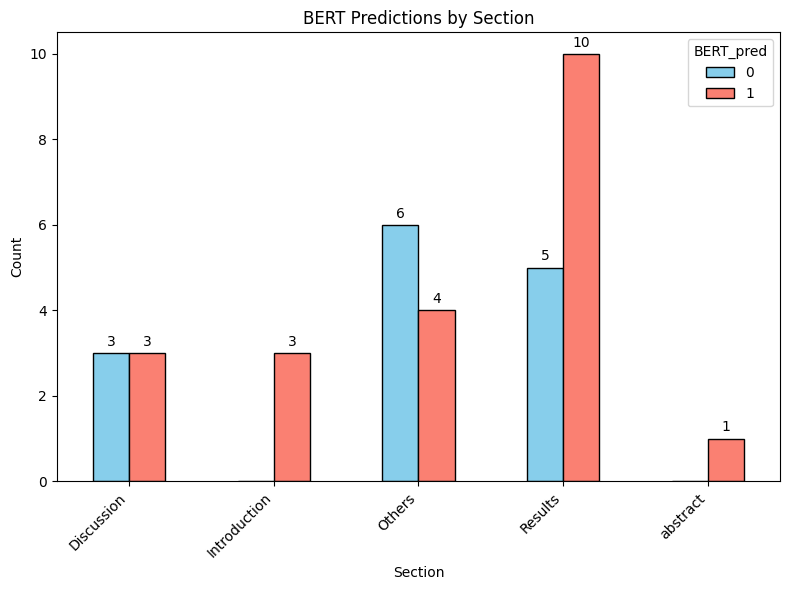

In [48]:
# visulize the filtering decision per section

counts = df_input.groupby(["section", "BERT_pred"]).size().unstack(fill_value=0)

# Plot
ax = counts.plot(
    kind="bar",
    stacked=False,
    figsize=(8,6),
    color={0:"skyblue", 1:"salmon"},
    edgecolor="black"   # outline
)

# Add numbers on top of each bar
for p in ax.patches:
    height = p.get_height()
    if height > 0: 
        ax.annotate(
            str(height),
            (p.get_x() + p.get_width()/2., height),
            ha='center', va='bottom',
            fontsize=10, color="black", xytext=(0,3),
            textcoords="offset points"
        )

plt.xlabel("Section")
plt.ylabel("Count")
plt.title("BERT Predictions by Section")
plt.xticks(rotation=45, ha="right")
plt.legend(title="BERT_pred")
plt.tight_layout()
plt.show()


In [49]:
# keep only the abstract/paragraph that BERT model predicts 1, 
# which means it contains the variant information we need
df_input_filtered = df_input[df_input['BERT_pred']==1]

In [50]:
df_input_filtered

,PMCID,section,paragraph,BERT_pred
0,PMC5628943,abstract,Large-scale sequencing efforts have captured a...,1
1,PMC5628943,Introduction,The rapid development of next-generation seque...,1
2,PMC5628943,Introduction,One well-studied example of a common congenita...,1
3,PMC5628943,Introduction,The large number of human IRF6 gene variants a...,1
4,PMC5628943,Results,To establish a zebrafish irf6 null model and i...,1
5,PMC5628943,Results,(A) Zebrafish irf6 gene structure composed of ...,1
6,PMC5628943,Results,It has been previously reported through gene e...,1
7,PMC5628943,Results,The 8bp deletion in the irf6 coding region was...,1
13,PMC5628943,Results,The conservation of human IRF6 protein functio...,1
14,PMC5628943,Results,(A) Experimental approach for characterizing p...,1


In [51]:
df_input_filtered.to_csv('example/LLM_input_PMC5628943.BERT_filtered.tsv',sep='\t',index=False,header=True)

# 2. Inference Module (instruction-tuned LLM)

In this step, we will run LLM with specifcally designed few shot prompt, to extract the SNV information from this paper.

In [52]:
df_input_filtered = pd.read_csv('example/LLM_input_PMC5628943.BERT_filtered.tsv',sep='\t')

In [33]:
# Initialize the model

model = LLM("/mnt/isilon/wang_lab/shared/Llama3_3/Llama-3.3-70B-Instruct/", # meta-llama/Llama-3.3-70B-Instruct
    tensor_parallel_size=4, #change it to number of GPU
    max_model_len=5000,
    swap_space=0,
    gpu_memory_utilization = 0.85
)

INFO 09-30 13:35:20 config.py:905] Defaulting to use mp for distributed inference
INFO 09-30 13:35:20 llm_engine.py:237] Initializing an LLM engine (v0.6.3.post1) with config: model='/mnt/isilon/wang_lab/shared/Llama3_3/Llama-3.3-70B-Instruct/', speculative_config=None, tokenizer='/mnt/isilon/wang_lab/shared/Llama3_3/Llama-3.3-70B-Instruct/', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config=None, rope_scaling=None, rope_theta=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.bfloat16, max_seq_len=5000, download_dir=None, load_format=LoadFormat.AUTO, tensor_parallel_size=4, pipeline_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, kv_cache_dtype=auto, quantization_param_path=None, device_config=cuda, decoding_config=DecodingConfig(guided_decoding_backend='outlines'), observability_config=ObservabilityConfig(otlp_traces_endpoint=None, collect_model_forward_time=False, collect_model_execute_tim

Loading safetensors checkpoint shards:   0% Completed | 0/30 [00:00<?, ?it/s]


(VllmWorkerProcess pid=1763181) INFO 09-30 13:39:12 model_runner.py:1067] Loading model weights took 32.8892 GB
(VllmWorkerProcess pid=1763180) INFO 09-30 13:39:12 model_runner.py:1067] Loading model weights took 32.8892 GB
(VllmWorkerProcess pid=1763179) INFO 09-30 13:39:12 model_runner.py:1067] Loading model weights took 32.8892 GB
INFO 09-30 13:39:12 model_runner.py:1067] Loading model weights took 32.8892 GB
INFO 09-30 13:39:17 distributed_gpu_executor.py:57] # GPU blocks: 26660, # CPU blocks: 0
INFO 09-30 13:39:17 distributed_gpu_executor.py:61] Maximum concurrency for 5000 tokens per request: 85.31x
(VllmWorkerProcess pid=1763179) INFO 09-30 13:39:17 model_runner.py:1395] Capturing the model for CUDA graphs. This may lead to unexpected consequences if the model is not static. To run the model in eager mode, set 'enforce_eager=True' or use '--enforce-eager' in the CLI.
(VllmWorkerProcess pid=1763181) INFO 09-30 13:39:17 model_runner.py:1395] Capturing the model for CUDA graphs. Th

In [34]:
tokenizer = AutoTokenizer.from_pretrained("/mnt/isilon/wang_lab/shared/Llama3_3/Llama-3.3-70B-Instruct") #meta-llama/Llama-3.3-70B-Instruct


In [35]:
# the fewshot prompt for SNV
snv_fewshot_prompts = """
Extract the information of gene, DNA mutation (or RSID), protein mutation, related disease, related phenotype, reason for pathogenicity, and pathogenicity from this research paper paragraph. Answer exactly in the format of ##gene||DNA mutation||protein mutation||disease||phenotype||pathogenicity reasoning||pathogenicity. Make sure to choose the pathogenicity only within these catogories [pathogenic, likely pathogenic, conflicting, likely benign, benign, unknown].

Example 1:
Paragraph: "Paragraph: We used zebra fish model to test some candidate variants for orofacial cleft (OFC). For ESRP2, variants R250Q and R667C rescued the molecular splicing of Arhgef11 in the Py2T assay, (Fig. 3E, Table 1)."
Output: 
##ESRP2||-||R250Q||orofacial cleft (OFC)||-||rescued the molecular splicing of Arhgef11 in the Py2T assay||benign
##ESRP2||-||R667C||orofacial cleft (OFC)||-||rescued the molecular splicing of Arhgef11 in the Py2T assay||benign

Example 2:
Paragraph: "The mutation c.123A>T in BRCA1 leads to a truncated protein p.Lys41*, associated with breast cancer. Functional assays showed loss of DNA repair function, indicating pathogenicity."
Output: 
##BRCA1||c.123A>T||p.Lys41*||breast cancer||-||loss of DNA repair function||pathogenic

Example 3:
Paragraph: "A variant in CFTR, p.Phe508del, causes cystic fibrosis. Studies confirmed defective chloride channels, confirming pathogenicity."
Output: 
##CFTR||-||p.Phe508del||cystic fibrosis||defective chloride channels||defective chloride channels||pathogenic
"""

# the fewshot prompt for gene fusion
gene_fusion_fewshot_prompt="""Extract gene fusion information from the paragraph in the format:  
##gene fusion||driver gene||partner gene||domain affected||related disease||experiment or functional result||pathogenicity

- The **gene fusion** should be in the format **GENE1::GENE2** as mentioned in the text.
- Identify the **driver gene** — this is typically the gene contributing the active domain (e.g., kinase, transcription factor) or the 3' gene in oncogenic fusions. Use context clues (e.g., "drives", "activates", "encodes") to determine.
- The **partner gene** is the fusion partner that contributes less functional consequence or is upstream/regulatory.

Example 1:  
"The EML4-ALK fusion occurs in lung cancer and activates the ALK kinase domain, leading to cell proliferation in vitro."  
##EML4::ALK||EML4||ALK||kinase domain||lung cancer||cell proliferation in vitro||pathogenic

Example 2:  
"A rare fusion between TMPRSS2 and ERG was found in prostate cancer, with no functional assay performed."  
##TMPRSS2::ERG||TMPRSS2||ERG||-||prostate cancer||not tested||unknown

Example 3:  
"We identified a novel RUNX1-RUNX1T1 fusion in acute myeloid leukemia, disrupting the DNA-binding domain of RUNX1."  
##RUNX1::RUNX1T1||RUNX1||RUNX1T1||DNA-binding domain||acute myeloid leukemia||disrupts DNA binding||pathogenic

Now extract from the paragraph below:
"""

# the fewshot prompt for gene CNV
cnv_fewshot_prompt="""
You are given a biomedical paragraph. Extract any copy number variants (CNVs) mentioned, including deletions or duplications. For each CNV, extract the following structured fields:

##CNV_type||chromosome_region||gene(s)||genomic_coordinates||disease||experiment or functional result||pathogenicity

- CNV_type: "deletion" or "duplication"
- chromosome_region: cytogenetic band (e.g., 22q11.2) if available
- gene(s): affected gene(s), separated by commas if multiple
- genomic_coordinates: if available (e.g., chr22:18000000-21000000)
- disease: associated disease name, or "unknown"
- experiment or functional result: brief summary of experimental or clinical findings
- pathogenicity: must be one of ["pathogenic", "likely pathogenic", "benign", "likely benign", "unknown", "conflicting"]

Example 1:
"The 22q11.2 deletion syndrome is caused by a ~3Mb deletion on chromosome 22, encompassing the TBX1 gene, and is associated with DiGeorge syndrome."
Answer:
##deletion||22q11.2||TBX1||chr22:18000000-21000000||DiGeorge syndrome||3Mb deletion spanning TBX1||pathogenic

Example 2:
"A microduplication of 16p11.2 involving the SH2B1 gene was observed in individuals with early-onset obesity."
Answer:
##duplication||16p11.2||SH2B1||unknown||early-onset obesity||Reported in multiple obesity patients||likely pathogenic

Example 3:
"An inherited 1q21.1 deletion encompassing the GJA5 gene was identified in a family with variable phenotypes, but with no consistent clinical presentation."
Answer:
##deletion||1q21.1||GJA5||unknown||unknown||Detected in unaffected individuals and patients||conflicting

Example 4:
"A 2q13 deletion involving NPHP1 was found in both patients with kidney disease and unaffected family members."
Answer:
##deletion||2q13||NPHP1||unknown||kidney disease||Lack of consistent phenotype among carriers||likely benign


Now extract the CNV(s) from the following paragraph:
"""

# the fewshot prompt for SV
sv_fewshot_prompt = """
You are given a biomedical paragraph. Extract any **structural variants (SVs)** mentioned, including deletions, duplications, inversions, insertions, and translocations. For each SV, extract the following structured fields:

##SV_type||gene(s)||chromosome_region||genomic_coordinates||related disease||experimental or clinical evidence||pathogenicity

- SV_type: one of ["deletion", "duplication", "inversion", "insertion", "translocation"]
- gene(s): affected gene(s), separated by commas if multiple
- chromosome_region: cytogenetic region (e.g., 22q11.2), or "unknown"
- genomic_coordinates: format "chr:start-end" if available, or "unknown"
- related disease: disease associated with the SV, or "unknown"
- experimental or clinical evidence: brief summary of supporting data
- pathogenicity: one of ["pathogenic", "likely pathogenic", "benign", "likely benign", "unknown", "conflicting"]

Example 1:
"A pathogenic inversion disrupting the F8 gene on Xq28 is a common cause of severe hemophilia A."
Answer:
##inversion||F8||Xq28||chrX:154180000-154300000||hemophilia A||Breakpoints identified in patients with severe phenotype||pathogenic

Example 2:
"A translocation between chromosomes 9 and 22 creates the BCR-ABL1 fusion gene, known as the Philadelphia chromosome, found in chronic myeloid leukemia."
Answer:
##translocation||BCR,ABL1||9q34,22q11||chr9:133729000-chr22:23632600||chronic myeloid leukemia||Philadelphia chromosome detected by FISH||pathogenic

Example 3:
"A 5q13.3 duplication involving the SMN1 and SMN2 genes has been reported in some individuals without symptoms."
Answer:
##duplication||SMN1,SMN2||5q13.3||chr5:70000000-70200000||unknown||Identified in asymptomatic carriers during screening||benign

Example 4:
"An insertion of ~1.5 kb in intron 1 of the FGFR2 gene has been observed in individuals with Apert syndrome."
Answer:
##insertion||FGFR2||10q26||chr10:123800000||Apert syndrome||Insertion disrupts regulatory elements in FGFR2 intron 1||likely pathogenic

Now extract the SV(s) from the following paragraph:
"""

In [36]:
# choose a prompt, here we use SNV prompt
chosen_prompt = snv_fewshot_prompts

In [57]:
# functions for tokenization and LLM output parsing

def generate_prompt(tmvar_corpus, few_shot_examples):
    
    prompts= []
    for paragraph in tmvar_corpus:
        prompt=f'{few_shot_examples}\nParagraph: \"{paragraph}\"'
        messages = [
            {'role': 'system', 'content': 
             '''You are an expert in genomics and bioinformatics. Extract the variant-related information from scientific publication paragraphs.'''},
            {'role': 'user', 'content': prompt},
        ]

        # Apply chat template
        templated_prompt = tokenizer.apply_chat_template(
            messages,
            add_generation_prompt=True,  # Adds necessary tokens for generation
            tokenize=False               # Returns a string
        )
        
        templated_prompt=templated_prompt.replace('Cutting Knowledge Date: December 2023\nToday Date: 26 Jul 2024\n\n','')
        prompts.append(templated_prompt)
    
    return prompts

# Function to convert LLM output to a DataFrame
def inference_to_df(output_test, pmc_ids, sec_for_inputs,col_names):
    rows = []
    for i, x in enumerate(output_test):
        pmc_id = pmc_ids[i]  # Assign the correct PMC ID
        sec = sec_for_inputs[i]
        for line in x.outputs[0].text.strip().splitlines():
            if "##" in line: # allow "##" not at the beginning
                parts = line.split("##", 1)[-1].strip().split("||") 
                rows.append([pmc_id] + [sec] + parts)
    
    df_cot = pd.DataFrame(rows)
    df_cot = df_cot.iloc[:,:9]
    #if df_cot.shape[1] == 7:  # Ensure the columns match the expected number
    df_cot.columns = col_names
    df_cot = df_cot.drop_duplicates()
    return df_cot

In [39]:
# define the column names for the parsed variants, this is the column name for SNV type
col_names = ['PMCID', 'section', 'gene', 'DNA mutation', 'protein mutation', 
             'disease', 'phenotype', 'LLM reasoning', 'pathogenicity']

In [60]:
# run LLM
all_inputs=list(df_input_filtered['paragraph'])
final_inputs = generate_prompt(all_inputs,chosen_prompt)
pmc_ids_for_inputs=list(df_input_filtered['PMCID'])
sec_for_inputs=list(df_input_filtered['section'])

print("Running inference ...")
# Run inference on all inputs
sampling_params = SamplingParams(temperature=0.6, top_p=0.3, max_tokens=1000) 
output = model.generate(final_inputs, sampling_params)

# Convert inference results to a single DataFrame
df_output = inference_to_df(output, pmc_ids_for_inputs, sec_for_inputs, col_names)

Running inference ...


Processed prompts: 100%|██████████| 21/21 [00:22<00:00,  1.06s/it, est. speed input: 771.31 toks/s, output: 106.04 toks/s]


In [61]:
df_output

,PMCID,section,gene,DNA mutation,protein mutation,disease,phenotype,LLM reasoning,pathogenicity
0,PMC5628943,abstract,IRF6,-,-,orofacial clefts,periderm rupture phenotype,retained partial or full protein function and ...,likely benign
1,PMC5628943,abstract,IRF6,-,-,orofacial clefts,periderm rupture phenotype,complete loss-of-function,pathogenic
2,PMC5628943,abstract,IRF6,-,-,orofacial clefts,periderm rupture phenotype,reduced function,likely pathogenic
3,PMC5628943,Introduction,-,-,-,-,-,-,unknown
4,PMC5628943,Introduction,IRF6,-,-,"orofacial clefts, Van der Woude syndrome (VWS)...","cleft lip and/or palate (CL/P), skin abnormali...",disruption of Irf6 led to a CL/P phenotype in ...,pathogenic
5,PMC5628943,Introduction,IRF6,-,-,-,ruptured embryos,required for the proper development of the emb...,unknown
6,PMC5628943,Results,irf6,c.772_779del,-,-,normal embryonic and craniofacial development,normal embryonic and craniofacial development ...,benign
7,PMC5628943,Results,irf6,-8bp deletion,truncated protein to 29 kD,-,"periderm rupture phenotype, incomplete perider...","frameshift and premature stop codon, lack of I...",pathogenic
8,PMC5628943,Results,irf6,+5bp insertion,-,-,-,-,unknown
9,PMC5628943,Results,IRF6,Δ8bp,-,embryonic lethality,"periderm rupture, separation of the animal pol...",failed to appropriately initiate epiboly,pathogenic


In [62]:
df_output.to_csv('example/LLM_output.tsv',sep='\t',index=False,header=True)

# 3. Normalization Module

## 3.1 quality filtering

This step make sure the gene name is human gene based on EnsemblRelease111, also make sure the pathoegnicity assignment is valid.

In [63]:
df = pd.read_csv('example/LLM_output.tsv',sep='\t')

In [64]:
from intervaltree import IntervalTree
import pyensembl
from Bio.Seq import Seq
from Bio import pairwise2, SeqIO
from pyensembl import EnsemblRelease

/home/wangp5/miniconda3/envs/vllm/lib/python3.10/site-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


In [65]:
data = EnsemblRelease(release=111, species='homo_sapiens')
gene_names = data.gene_names()
gene_names = [gene for gene in gene_names if gene !='']


In [66]:
# filter out the gene name that is not human gene
df = df[df['gene'].isin(gene_names)]
df=df[(df['DNA mutation']!='-') | (df['protein mutation']!='-')]

In [67]:
# filter out the pathogenicity assiganment that is not within the predefined categories (in prompt)
df["pathogenicity"] = df["pathogenicity"].replace("-", "unknown")
# refine patho classification
valid_patho = ['pathogenic', 'likely pathogenic', 'conflicting', 'likely benign', 'benign', 'unknown']
df = df[df['pathogenicity'].isin(valid_patho)]

In [68]:
df

,PMCID,section,gene,DNA mutation,protein mutation,disease,phenotype,LLM reasoning,pathogenicity
9,PMC5628943,Results,IRF6,Δ8bp,-,embryonic lethality,"periderm rupture, separation of the animal pol...",failed to appropriately initiate epiboly,pathogenic
10,PMC5628943,Results,IRF6,5 bp insertion in exon 6,-,embryonic lethality,"periderm rupture, separation of the animal pol...",produced the same set of phenotypes as the Δ8b...,pathogenic
11,PMC5628943,Results,IRF6,irf6 Δ8bp,p.Trp264*,-,"undetectable irf6 transcripts, undetectable Ir...",irf6 transcript destabilization and degradatio...,pathogenic
12,PMC5628943,Results,IRF6,-,p.F252L,cleft lip/palate (CL/P),periderm rupture phenotype,unable to rescue the maternal-null irf6 -/- ru...,likely pathogenic
13,PMC5628943,Results,IRF6,-,p.V274I,cleft lip/palate (CL/P),periderm rupture phenotype,able to rescue the rupture phenotype,benign
16,PMC5628943,Results,IRF6,-,p.R45Q,orofacial cleft,-,rescued the periderm rupture phenotype of mate...,unknown
17,PMC5628943,Results,IRF6,-,p.R45W,orofacial cleft,-,rescued the periderm rupture phenotype of mate...,unknown
18,PMC5628943,Results,IRF6,-,p.G70R,orofacial cleft,-,rescued the periderm rupture phenotype of mate...,unknown
19,PMC5628943,Results,IRF6,-,p.V274I,orofacial cleft,-,"high allele frequency in ExAC, considered beni...",benign
20,PMC5628943,Results,IRF6,-,p.D354N,orofacial cleft,-,"non-conserved in zebrafish irf6, found in ExAC...",likely benign


## 3.2 variant_parser (regex)

In [69]:
import re

In [70]:
# Dictionary to convert one-letter to three-letter amino acid codes
aa_dict = {
    'A': 'Ala', 'R': 'Arg', 'N': 'Asn', 'D': 'Asp', 'C': 'Cys',
    'Q': 'Gln', 'E': 'Glu', 'G': 'Gly', 'H': 'His', 'I': 'Ile',
    'L': 'Leu', 'K': 'Lys', 'M': 'Met', 'F': 'Phe', 'P': 'Pro',
    'S': 'Ser', 'T': 'Thr', 'W': 'Trp', 'Y': 'Tyr', 'V': 'Val',
    '*': 'Ter'  # Stop codon
    
}

def parse_protein_variant(variant):
    """Parse protein variant and return (position, from_aa, to_aa)"""
    if not isinstance(variant, str) or variant in ["-", ""]:
        return None, None, None

    # Normalize input
    variant = variant.replace("p.", "").replace("P.", "")
    variant = variant.replace("Ter", "*").replace("sp", "*").replace("stop", "*")
    variant = variant.replace("DEL", "del").replace("Del", "del").replace("INS", "ins").replace("Ins", "ins")

    patterns = [
        # 3-letter substitution + frameshift + *
        (r"([A-Za-z]{3})(\d+)([A-Za-z]{3})fs\*(\d+)", lambda m: (m[1], aa_dict.get(m[0], m[0]), f"{m[2]}fs*{m[3]}")),
        # 3-letter substitution
        (r"\b([A-Za-z]{3})(\d+)([A-Za-z]{3})\b", lambda m: (m[1], m[0], m[2])),
        # 1-letter substitution
        (r"\b([A-Z])(\d+)([A-Z])\b", lambda m: (m[1], aa_dict.get(m[0], m[0]), aa_dict.get(m[2], m[2]))),
        # frameshift + stop
        (r"([A-Za-z]{3})(\d+)fs\*(\d+)", lambda m: (m[1], aa_dict.get(m[0], m[0]), f"fs*{m[2]}")),
        (r"([A-Z])(\d+)fs\*(\d+)", lambda m: (m[1], aa_dict.get(m[0], m[0]), f"fs*{m[2]}")),
        # frameshift + no stop
        (r"([A-Za-z]{3})(\d+)fs\*", lambda m: (m[1], aa_dict.get(m[0], m[0]), "fs*")),
        (r"([A-Z])(\d+)fs\*", lambda m: (m[1], aa_dict.get(m[0], m[0]), "fs*")),
        # simple frameshift
        (r"\b([A-Za-z]{3})(\d+)fs\b", lambda m: (m[1], aa_dict.get(m[0], m[0]), "fs")),
        (r"\b([A-Z])(\d+)fs\b", lambda m: (m[1], aa_dict.get(m[0], m[0]), "fs")),
        # deletion
        (r"\b([A-Za-z]{3})(\d+)del\b", lambda m: (m[1], aa_dict.get(m[0], m[0]), "del")),
        (r"\b([A-Z])(\d+)del\b", lambda m: (m[1], aa_dict.get(m[0], m[0]), "del")),
        # termination
        (r"([A-Za-z]{3})(\d+)\*", lambda m: (m[1], aa_dict.get(m[0], m[0]), "Ter")),
        (r"([A-Z])(\d+)\*", lambda m: (m[1], aa_dict.get(m[0], m[0]), "Ter")),
        # insertion
        (r"\b(\d+)ins([A-Z])\b", lambda m: (m[0], "ins", aa_dict.get(m[1], m[1]))),
        (r"\b(\d+)ins([A-Za-z]{3})\b", lambda m: (m[0], "ins", aa_dict.get(m[1], m[1])))
    ]

    for pattern, handler in patterns:
        match = re.search(pattern, variant)
        if match:
            return handler(match.groups())

    return None, None, None


def parse_dna_variant(variant):
    """Return (pos, from, to, rsid) from a DNA/cDNA mutation string."""
    if not isinstance(variant, str) or variant.strip() in ["-", ""]:
        return None, None, None, None

    variant = re.sub(r"\s+", "", variant) #removes all whitespace characters
    variant = variant.replace("→", ">").replace("c.", "").replace("C.", "").replace("g.", "").replace("G.", "")

    patterns = [
        (r"\b([\d\+]+)([ATGC]+)[-/]*[>/]([ATGC]+)\b", lambda m: (m[0], m[1], m[2], None)),
        (r"\b(\d+)([ATGC]+)[-/]*[>/]([ATGC]+)\b", lambda m: (m[0], m[1], m[2], None)),
        (r"\b([ATGC]+)(\d+)([ATGC]+)\b", lambda m: (m[1], m[0], m[2], None)),
        (r"\b(\d+)del([ATGC]*)\b", lambda m: (m[0], m[1] if m[1] else "-", "del", None)),
        (r"\bdel(\d+)([ATGC]*)\b", lambda m: (m[0], m[1] if m[1] else "-", "del", None)),
        (r"\b(\d+_\d+)del([ATGC]*)\b", lambda m: (m[0], m[1] if m[1] else "-", "del", None)),
        (r"\b([\d_]+)ins([ATGC]+)\b", lambda m: (m[0], "ins", m[1], None)),
        (r"\bins([\d_]+)([ATGC]+)\b", lambda m: (m[0], "ins", m[1], None)),
        (r"\b([\d_]+)dup([ATGC]+)\b", lambda m: (m[0], "dup", m[1], None)),
        (r"\bdup([\d_]+)([ATGC]+)\b", lambda m: (m[0], "dup", m[1], None)),
        (r"\b(rs\d+)([ATGC]+)[-/]*[>/]([ATGC]+)\b", lambda m: (None, m[1], m[2], m[0])),
        (r"\b(rs\d+)\b", lambda m: (None, None, None, m[0]))
    ]

    for pattern, handler in patterns:
        match = re.search(pattern, variant, re.IGNORECASE)
        if match:
            #turn result into upper case
            groups_upper = tuple(g.upper() if isinstance(g, str) and g.upper() in ['A','T','C','G'] else g for g in match.groups())
            return handler(groups_upper)

    return None, None, None, None



# Evaluate
###############Protein############
lst_of_test = ['p.Lys1129Ter','p.Lys1129*','P.p.Lys1129Ter',
               'p.(lys121arg)','Lys121arg','Lys121Arg',
               'A21*','T32Ter','T342sp','K32stop',
               'A12K','K32N',
               'A21del','Lys32del','K3DEL',
               '21insA','32insLys','3INSK',
               'A21fs','Lys32fs',
               'A21fs*','Lys32fs*','A21fs*21','Lys32fs*31',
               '(Pro588Argfs*18)'
              ]

lst_of_test_results = ['Lys1129Ter','Lys1129Ter','Lys1129Ter',
               'lys121arg','Lys121arg','Lys121Arg',
               'Ala21Ter','Thr32Ter','Thr342Ter','Lys32Ter',
               'Ala12Lys','Lys32Asn',
               'Ala21del','Lys32del','Lys3del',
               'ins21Ala','ins32Lys','ins3Lys',
               'Ala21fs','Lys32fs',
               'Ala21fs*','Lys32fs*','Ala21fs*21','Lys32fs*31',
               'Pro588Argfs*18'
              ]

results = []
for i, test_str in enumerate(lst_of_test):
    parsed = parse_protein_variant(test_str)
    try:
        if not parsed[0] or not parsed[1] or not parsed[2]:
            result_str = "None"
        elif parsed[1] == "ins":
            result_str = f"ins{parsed[0]}{parsed[2]}"
        else:
            result_str = f"{parsed[1]}{parsed[0]}{parsed[2]}"
        results.append((test_str, result_str, lst_of_test_results[i],result_str == lst_of_test_results[i]))
    except Exception as e:
        results.append((test_str, f"ERROR: {e}", False))

if len([re for re in results if not re[3]])==0:
    print("Pass all tests!")
else:
    print("Failed cases:")
    print([re for re in results if not re[3]])
    

###########cDNA###########
# Example test cases and expected results
test_variants = [
    "c.123A>G", "c.(123A>G)","G123A", "123delA", "del123T",
    "c.201 + 1G > T", "c.201+1g > t",
    "123_456del", "123insA", "ins123C",
    "123dupT", "dup123G", "rs123", "RS1029524",
    "rs456C>T", "g.456T>G", "  321  A  >  T"
]
expected_outputs = [
    ("123", "A", "G", None), ("123", "A", "G", None), ("123", "G", "A", None), ("123", "A", "del", None), ("123", "T", "del", None),
    ("201+1","G","T",None),("201+1","G","T",None),
    ("123_456", "-", "del", None), ("123", "ins", "A", None), ("123", "ins", "C", None),
    ("123", "dup", "T", None), ("123", "dup", "G", None), (None, None, None, "rs123"),(None, None, None, "RS1029524"),
    (None, "C", "T", "rs456"), ("456", "T", "G", None), ("321", "A", "T", None)
]

# Evaluate function
results = []
for var, expected in zip(test_variants, expected_outputs):
    try:
        parsed = parse_dna_variant(var)
        results.append((var, parsed, expected,parsed == expected))
    except Exception as e:
        results.append((var, f"ERROR: {e}", False))

if len([re for re in results if not re[3]])==0:
    print("Pass all tests!")
else:
    print("Failed cases:")
    print([re for re in results if not re[3]])  


Pass all tests!
Pass all tests!


In [71]:
%%time
# Apply functions to extract normalized variant representation
df[['dna_pos', 'dna_from', 'dna_to', 'RSID']] = df['DNA mutation'].apply(lambda x: pd.Series(parse_dna_variant(x)))
df[['aa_pos', 'aa_from', 'aa_to']] = df['protein mutation'].apply(lambda x: pd.Series(parse_protein_variant(x)))
df['dna_change']=df['dna_from']+df['dna_pos']+df['dna_to']
df['aa_change']=df['aa_from']+df['aa_pos']+df['aa_to']



CPU times: user 6.1 ms, sys: 0 ns, total: 6.1 ms
Wall time: 6.18 ms


In [72]:
df

,PMCID,section,gene,DNA mutation,protein mutation,disease,phenotype,LLM reasoning,pathogenicity,dna_pos,dna_from,dna_to,RSID,aa_pos,aa_from,aa_to,dna_change,aa_change
9,PMC5628943,Results,IRF6,Δ8bp,-,embryonic lethality,"periderm rupture, separation of the animal pol...",failed to appropriately initiate epiboly,pathogenic,None,None,None,None,None,None,None,NaN,NaN
10,PMC5628943,Results,IRF6,5 bp insertion in exon 6,-,embryonic lethality,"periderm rupture, separation of the animal pol...",produced the same set of phenotypes as the Δ8b...,pathogenic,None,None,None,None,None,None,None,NaN,NaN
11,PMC5628943,Results,IRF6,irf6 Δ8bp,p.Trp264*,-,"undetectable irf6 transcripts, undetectable Ir...",irf6 transcript destabilization and degradatio...,pathogenic,None,None,None,None,264,Trp,Ter,NaN,Trp264Ter
12,PMC5628943,Results,IRF6,-,p.F252L,cleft lip/palate (CL/P),periderm rupture phenotype,unable to rescue the maternal-null irf6 -/- ru...,likely pathogenic,None,None,None,None,252,Phe,Leu,NaN,Phe252Leu
13,PMC5628943,Results,IRF6,-,p.V274I,cleft lip/palate (CL/P),periderm rupture phenotype,able to rescue the rupture phenotype,benign,None,None,None,None,274,Val,Ile,NaN,Val274Ile
16,PMC5628943,Results,IRF6,-,p.R45Q,orofacial cleft,-,rescued the periderm rupture phenotype of mate...,unknown,None,None,None,None,45,Arg,Gln,NaN,Arg45Gln
17,PMC5628943,Results,IRF6,-,p.R45W,orofacial cleft,-,rescued the periderm rupture phenotype of mate...,unknown,None,None,None,None,45,Arg,Trp,NaN,Arg45Trp
18,PMC5628943,Results,IRF6,-,p.G70R,orofacial cleft,-,rescued the periderm rupture phenotype of mate...,unknown,None,None,None,None,70,Gly,Arg,NaN,Gly70Arg
19,PMC5628943,Results,IRF6,-,p.V274I,orofacial cleft,-,"high allele frequency in ExAC, considered beni...",benign,None,None,None,None,274,Val,Ile,NaN,Val274Ile
20,PMC5628943,Results,IRF6,-,p.D354N,orofacial cleft,-,"non-conserved in zebrafish irf6, found in ExAC...",likely benign,None,None,None,None,354,Asp,Asn,NaN,Asp354Asn


## 3.3 map to transcripts

In [73]:
import pandas as pd
from pyensembl import EnsemblRelease
from Bio.Seq import Seq
import numpy as np
import logging
logging.getLogger("pyensembl.sequence_data").setLevel(logging.ERROR)


In [74]:
# Initialize Ensembl reference (GRCh38, release 111)
ensembl = EnsemblRelease(111, species='homo_sapiens')

aa_dict = {
    'A': 'Ala', 'R': 'Arg', 'N': 'Asn', 'D': 'Asp', 'C': 'Cys',
    'Q': 'Gln', 'E': 'Glu', 'G': 'Gly', 'H': 'His', 'I': 'Ile',
    'L': 'Leu', 'K': 'Lys', 'M': 'Met', 'F': 'Phe', 'P': 'Pro',
    'S': 'Ser', 'T': 'Thr', 'W': 'Trp', 'Y': 'Tyr', 'V': 'Val',
    '*': 'Ter'  # Stop codon
}

def get_cds_genomic_positions(tx):
    ranges = tx.coding_sequence_position_ranges
    genomic_positions = []
    for start, end in ranges:
        if tx.strand == "+":
            genomic_positions.extend(range(start, end + 1))
        else:
            # Reverse direction for minus strand
            genomic_positions.extend(range(end, start - 1, -1))
    return genomic_positions


def protein_to_genomic(gene_name, aa_pos, aa_ref=None):
    try:
        #print(len(ensembl.genes_by_name(gene_name)))
        genes = ensembl.genes_by_name(gene_name)
    except ValueError:
        #print(f'gene {gene_name} not found')
        return None  # Gene not found
    
    all_match_tx = []
    for gene in genes:
        for tx in gene.transcripts:
            if tx.is_protein_coding:
                try:
                    cds = tx.coding_sequence
                    aa_seq = Seq(cds).translate()

                    if aa_pos <= len(aa_seq):
                        aa_from_aa_seq = aa_dict.get(aa_seq[aa_pos - 1])
                        if aa_ref:
                            
                            #check if the provided aa same as ref aa based on pos
                            if aa_ref!=aa_from_aa_seq:
                                #print('ref aa not match')
                                continue
                                
                        codon_start = (aa_pos - 1) * 3

                        # Get full CDS genomic position map
                        cds_genome = get_cds_genomic_positions(tx)

                        # get genome coodirnate based on codon_start
                        codon_coords = cds_genome[codon_start:codon_start+3]
                        # get cDNA codon
                        codon = cds[codon_start:codon_start + 3]
                        # get genome ref
                        if tx.strand=='+':
                            genome_codon = codon
                        else:
                            genome_codon = str(Seq(codon).reverse_complement())

                        all_match_tx.append({
                            "transcript_id": tx.transcript_id,
                            "chromosome": tx.contig,
                            "strand": tx.strand,
                            "genomic_coords": codon_coords,
                            "ref_aa": aa_seq[aa_pos - 1],
                            "codon_cDNA": codon,
                            'gnomic_codon': genome_codon
                        })
                        
                    #else:
                        #print('ref tx is too short')
                except Exception:
                    continue
    if len(all_match_tx) == 0:
        return None
    return all_match_tx


def cdna_to_genomic(gene_name, cdna_pos, ref_nt=None):
    try:
        genes = ensembl.genes_by_name(gene_name)
    except ValueError:
        #print(f'Gene {gene_name} not found')
        return None

    matches = []

    for gene in genes:
        for tx in gene.transcripts:
            if tx.is_protein_coding:
                try:
                    # Get spliced transcript (cDNA sequence)
                    cdna_seq = tx.coding_sequence
                    if cdna_pos > len(cdna_seq):
                        continue
                    
                    nt_from_tx = cdna_seq[cdna_pos - 1]  # 1-based to 0-based
                    
                    # Optional: check ref nucleotide match
                    if ref_nt:
                        if nt_from_tx.upper() != ref_nt.upper():
                            continue

                    # Use spliced offset for genomic mapping
                    cds_genome = get_cds_genomic_positions(tx)
                    
                    genome_coord = cds_genome[cdna_pos - 1]
                    
                    # get genome ref
                    if tx.strand=='+':
                        genome_ref = nt_from_tx
                    else:
                        genome_ref = str(Seq(nt_from_tx).complement())
                        
                    matches.append({
                        "transcript_id": tx.transcript_id,
                        "chromosome": tx.contig,
                        "strand": tx.strand,
                        "genomic_coord": genome_coord,
                        "ref_cDNA": nt_from_tx,
                        "genomic_ref": genome_ref
                    })
                except Exception as e:
                    continue
    if len(matches) == 0:
        return None
    return matches

def annotate_row(row):
    gene = row['gene']

    if gene=='-' or gene=='nan' or gene==np.nan:
        return None
    
    # Use cDNA info first
    if pd.notnull(row.get('dna_pos')) and pd.notnull(row.get('dna_from')):
        try:
            cdna_coord = cdna_to_genomic(gene, int(row['dna_pos']), row['dna_from'])
            if cdna_coord!=None:
                return cdna_coord
           
        except Exception as e:
            return f'cdna_error: {e}'
        
    # Use protein info if available
    elif pd.notnull(row.get('aa_pos')) and pd.notnull(row.get('aa_from')):
        try:
            return protein_to_genomic(gene, int(row['aa_pos']), row['aa_from'])
        except Exception as e:
            return f'protein_error: {e}'
    
    
    
    return None




In [75]:
%%time
df['genomic_coord_result'] = df.apply(annotate_row,axis=1)

CPU times: user 284 ms, sys: 446 ms, total: 730 ms
Wall time: 2.29 s


In [76]:
df

,PMCID,section,gene,DNA mutation,protein mutation,disease,phenotype,LLM reasoning,pathogenicity,dna_pos,dna_from,dna_to,RSID,aa_pos,aa_from,aa_to,dna_change,aa_change,genomic_coord_result
9,PMC5628943,Results,IRF6,Δ8bp,-,embryonic lethality,"periderm rupture, separation of the animal pol...",failed to appropriately initiate epiboly,pathogenic,None,None,None,None,None,None,None,NaN,NaN,None
10,PMC5628943,Results,IRF6,5 bp insertion in exon 6,-,embryonic lethality,"periderm rupture, separation of the animal pol...",produced the same set of phenotypes as the Δ8b...,pathogenic,None,None,None,None,None,None,None,NaN,NaN,None
11,PMC5628943,Results,IRF6,irf6 Δ8bp,p.Trp264*,-,"undetectable irf6 transcripts, undetectable Ir...",irf6 transcript destabilization and degradatio...,pathogenic,None,None,None,None,264,Trp,Ter,NaN,Trp264Ter,None
12,PMC5628943,Results,IRF6,-,p.F252L,cleft lip/palate (CL/P),periderm rupture phenotype,unable to rescue the maternal-null irf6 -/- ru...,likely pathogenic,None,None,None,None,252,Phe,Leu,NaN,Phe252Leu,"[{'transcript_id': 'ENST00000367021', 'chromos..."
13,PMC5628943,Results,IRF6,-,p.V274I,cleft lip/palate (CL/P),periderm rupture phenotype,able to rescue the rupture phenotype,benign,None,None,None,None,274,Val,Ile,NaN,Val274Ile,"[{'transcript_id': 'ENST00000367021', 'chromos..."
16,PMC5628943,Results,IRF6,-,p.R45Q,orofacial cleft,-,rescued the periderm rupture phenotype of mate...,unknown,None,None,None,None,45,Arg,Gln,NaN,Arg45Gln,"[{'transcript_id': 'ENST00000367021', 'chromos..."
17,PMC5628943,Results,IRF6,-,p.R45W,orofacial cleft,-,rescued the periderm rupture phenotype of mate...,unknown,None,None,None,None,45,Arg,Trp,NaN,Arg45Trp,"[{'transcript_id': 'ENST00000367021', 'chromos..."
18,PMC5628943,Results,IRF6,-,p.G70R,orofacial cleft,-,rescued the periderm rupture phenotype of mate...,unknown,None,None,None,None,70,Gly,Arg,NaN,Gly70Arg,"[{'transcript_id': 'ENST00000367021', 'chromos..."
19,PMC5628943,Results,IRF6,-,p.V274I,orofacial cleft,-,"high allele frequency in ExAC, considered beni...",benign,None,None,None,None,274,Val,Ile,NaN,Val274Ile,"[{'transcript_id': 'ENST00000367021', 'chromos..."
20,PMC5628943,Results,IRF6,-,p.D354N,orofacial cleft,-,"non-conserved in zebrafish irf6, found in ExAC...",likely benign,None,None,None,None,354,Asp,Asn,NaN,Asp354Asn,"[{'transcript_id': 'ENST00000367021', 'chromos..."


## 3.4 map to genome coordiantes

In [77]:
import pandas as pd
import ast
from Bio.Seq import Seq
from Bio.Data import CodonTable

In [78]:
# 3-letter to 1-letter amino acid dictionary
aa_dict = {
    'A': 'Ala', 'R': 'Arg', 'N': 'Asn', 'D': 'Asp', 'C': 'Cys',
    'Q': 'Gln', 'E': 'Glu', 'G': 'Gly', 'H': 'His', 'I': 'Ile',
    'L': 'Leu', 'K': 'Lys', 'M': 'Met', 'F': 'Phe', 'P': 'Pro',
    'S': 'Ser', 'T': 'Thr', 'W': 'Trp', 'Y': 'Tyr', 'V': 'Val',
    '*': 'Ter'
}
aa_3to1 = {v: k for k, v in aa_dict.items()}

# Amino acid to RNA codon table
standard_table = CodonTable.unambiguous_rna_by_name["Standard"]
aa_to_codons = {}
for codon, aa in standard_table.forward_table.items():
    aa_to_codons.setdefault(aa, []).append(codon)
for codon in standard_table.stop_codons:
    aa_to_codons.setdefault("*", []).append(codon)


def get_cdna_variant(tx, dna_pos, dna_from, dna_to):
    if 'ref_cDNA' not in tx or 'genomic_coord' not in tx:
        return None

    if str(tx['ref_cDNA']).upper() != str(dna_from).upper():
        return None

    pos = tx['genomic_coord']
    ref = str(dna_from).upper()
    alt = str(dna_to).upper()

    # Adjust for strand
    if tx['strand'] == '-':
        ref = str(Seq(ref).complement())
        alt = str(Seq(alt).complement())

    return {
        'chr': tx['chromosome'],
        'pos': pos,
        'ref': ref,
        'alt': alt,
        'transcript_id': tx['transcript_id']
    }

    
    
def get_protein_variant(tx, aa_pos, aa_from, aa_to):
    if 'ref_aa' not in tx or 'genomic_coords' not in tx or 'gnomic_codon' not in tx:
        return []

    # Convert 3-letter to 1-letter amino acid
    aa_from_1 = aa_3to1.get(str(aa_from).capitalize())
    aa_to_1 = aa_3to1.get(str(aa_to).capitalize())
    if not aa_from_1 or not aa_to_1:
        return []

    if tx['ref_aa'].upper() != aa_from_1:
        return []

    ref_codon = tx['gnomic_codon'].upper()
    strand = tx['strand']
    coords = tx['genomic_coords']
    variants = []

    for alt_rna_codon in aa_to_codons.get(aa_to_1, []):
        # Convert RNA to DNA
        alt_dna_codon = alt_rna_codon.replace("U", "T")

        if strand == '+':
            alt_genomic_codon = alt_dna_codon
            start_coord = coords[0]
        else:
            alt_genomic_codon = str(Seq(alt_dna_codon).reverse_complement())
            start_coord = coords[-1]

        if ref_codon != alt_genomic_codon:
            variants.append({
                'chr': tx['chromosome'],
                'pos': start_coord,  # always the leftmost genomic position
                'ref': ref_codon,
                'alt': alt_genomic_codon,
                'transcript_id': tx['transcript_id'],
                'aa_from': aa_from,
                'aa_to': aa_to
            })

    return variants


def parse_variant_from_transcript(row, mane_tx_dict):
    gene = row['gene']
    results = []
    if row['genomic_coord_result']==None:
        return results
    
    try:
        if isinstance(row['genomic_coord_result'], str):
            if row['genomic_coord_result'].strip().startswith("[{"):
                transcripts = ast.literal_eval(row['genomic_coord_result'])
            else:
                return []  
        else:
            transcripts = row['genomic_coord_result']
    except Exception:
        return [] 
        
    # Extract variant information
    dna_pos = row.get('dna_pos')
    dna_from = row.get('dna_from')
    dna_to   = row.get('dna_to')
    aa_pos   = row.get('aa_pos')
    aa_from  = row.get('aa_from')
    aa_to    = row.get('aa_to')

    mane_tx = mane_tx_dict.get(gene)
    

    for tx in transcripts:
        is_mane = (tx['transcript_id'] == mane_tx)

        if 'ref_aa' in tx and pd.notnull(aa_pos) and pd.notnull(aa_from) and pd.notnull(aa_to):
            variants = get_protein_variant(tx, aa_pos, aa_from, aa_to)
        elif 'ref_cDNA' in tx and pd.notnull(dna_pos) and pd.notnull(dna_from) and pd.notnull(dna_to):
            variant = get_cdna_variant(tx, dna_pos, dna_from, dna_to)
            variants = [variant] if variant else []
        else:
            continue

        for var in variants:
            if var:
                var_clean = {
                    'chr': var['chr'],
                    'pos': var['pos'],
                    'ref': var['ref'],
                    'alt': var['alt'],
                    'MANE_transcript_used': str(is_mane)
                }
                results.append(var_clean)

    # Deduplicate by chr, pos, ref, alt
    seen = set()
    unique_results = []
    for r in results:
        key = (r['chr'], r['pos'], r['ref'], r['alt'])
        if key not in seen:
            seen.add(key)
            unique_results.append(r)

    return unique_results if unique_results else None



In [79]:
# load MANE select transcipt
mane_select = pd.read_csv('example/mane.bed',sep='\t',header=None)
mane_select['ENST']=mane_select[3].apply(lambda x: x.split('.')[0])
mane_tx_df = mane_select[[18,'ENST']].rename(columns={18:'gene'})
mane_tx_dict = dict(zip(mane_tx_df['gene'], mane_tx_df['ENST']))

In [80]:
%%time
df['parsed_variants'] = df.apply(lambda row:parse_variant_from_transcript(row, mane_tx_dict), axis=1)


CPU times: user 1.27 ms, sys: 126 μs, total: 1.4 ms
Wall time: 1.41 ms


In [81]:
df

,PMCID,section,gene,DNA mutation,protein mutation,disease,phenotype,LLM reasoning,pathogenicity,dna_pos,dna_from,dna_to,RSID,aa_pos,aa_from,aa_to,dna_change,aa_change,genomic_coord_result,parsed_variants
9,PMC5628943,Results,IRF6,Δ8bp,-,embryonic lethality,"periderm rupture, separation of the animal pol...",failed to appropriately initiate epiboly,pathogenic,None,None,None,None,None,None,None,NaN,NaN,None,[]
10,PMC5628943,Results,IRF6,5 bp insertion in exon 6,-,embryonic lethality,"periderm rupture, separation of the animal pol...",produced the same set of phenotypes as the Δ8b...,pathogenic,None,None,None,None,None,None,None,NaN,NaN,None,[]
11,PMC5628943,Results,IRF6,irf6 Δ8bp,p.Trp264*,-,"undetectable irf6 transcripts, undetectable Ir...",irf6 transcript destabilization and degradatio...,pathogenic,None,None,None,None,264,Trp,Ter,NaN,Trp264Ter,None,[]
12,PMC5628943,Results,IRF6,-,p.F252L,cleft lip/palate (CL/P),periderm rupture phenotype,unable to rescue the maternal-null irf6 -/- ru...,likely pathogenic,None,None,None,None,252,Phe,Leu,NaN,Phe252Leu,"[{'transcript_id': 'ENST00000367021', 'chromos...","[{'chr': '1', 'pos': 209790799, 'ref': 'GAA', ..."
13,PMC5628943,Results,IRF6,-,p.V274I,cleft lip/palate (CL/P),periderm rupture phenotype,able to rescue the rupture phenotype,benign,None,None,None,None,274,Val,Ile,NaN,Val274Ile,"[{'transcript_id': 'ENST00000367021', 'chromos...","[{'chr': '1', 'pos': 209790733, 'ref': 'GAC', ..."
16,PMC5628943,Results,IRF6,-,p.R45Q,orofacial cleft,-,rescued the periderm rupture phenotype of mate...,unknown,None,None,None,None,45,Arg,Gln,NaN,Arg45Gln,"[{'transcript_id': 'ENST00000367021', 'chromos...","[{'chr': '1', 'pos': 209801279, 'ref': 'CCG', ..."
17,PMC5628943,Results,IRF6,-,p.R45W,orofacial cleft,-,rescued the periderm rupture phenotype of mate...,unknown,None,None,None,None,45,Arg,Trp,NaN,Arg45Trp,"[{'transcript_id': 'ENST00000367021', 'chromos...","[{'chr': '1', 'pos': 209801279, 'ref': 'CCG', ..."
18,PMC5628943,Results,IRF6,-,p.G70R,orofacial cleft,-,rescued the periderm rupture phenotype of mate...,unknown,None,None,None,None,70,Gly,Arg,NaN,Gly70Arg,"[{'transcript_id': 'ENST00000367021', 'chromos...","[{'chr': '1', 'pos': 209796517, 'ref': 'CCC', ..."
19,PMC5628943,Results,IRF6,-,p.V274I,orofacial cleft,-,"high allele frequency in ExAC, considered beni...",benign,None,None,None,None,274,Val,Ile,NaN,Val274Ile,"[{'transcript_id': 'ENST00000367021', 'chromos...","[{'chr': '1', 'pos': 209790733, 'ref': 'GAC', ..."
20,PMC5628943,Results,IRF6,-,p.D354N,orofacial cleft,-,"non-conserved in zebrafish irf6, found in ExAC...",likely benign,None,None,None,None,354,Asp,Asn,NaN,Asp354Asn,"[{'transcript_id': 'ENST00000367021', 'chromos...","[{'chr': '1', 'pos': 209789784, 'ref': 'ATC', ..."


In [82]:
df.loc[29].values

array(['PMC5628943', 'Discussion', 'IRF6', '-', 'p.R45W',
       'Van der Woude Syndrome (VWS)',
       'variable expressivity of phenotypes',
       'rescued maternal-null irf6 -/- periderm rupture and function quantitatively to the same degree as wild type IRF6',
       'likely benign', None, None, None, None, '45', 'Arg', 'Trp', nan,
       'Arg45Trp',
       list([{'transcript_id': 'ENST00000367021', 'chromosome': '1', 'strand': '-', 'genomic_coords': [209801281, 209801280, 209801279], 'ref_aa': 'R', 'codon_cDNA': 'CGG', 'gnomic_codon': 'CCG'}]),
       list([{'chr': '1', 'pos': 209801279, 'ref': 'CCG', 'alt': 'CCA', 'MANE_transcript_used': 'True'}])],
      dtype=object)

## 3.5 disease/phenotype normalization

This step we use PubMedBERT to calculate the sementic similarity between the disease and phenotype from LLM with the MONDO disease and HPO term. This will provide a standardized disease name or phenotype term.

In [83]:
from sentence_transformers import SentenceTransformer, util
from difflib import SequenceMatcher
import numpy as np

INFO:datasets:PyTorch version 2.4.0 available.
INFO:datasets:Polars version 0.20.31 available.


In [85]:
mondo_df = pd.read_csv('example/MONDO_id_name.tsv',sep='\t',header=0)
mondo_dx_lst = list(mondo_df['MONDO name'])

In [86]:
# load the PubMedBERT model for disease/phenotype name embedding
emb_model = SentenceTransformer('neuml/pubmedbert-base-embeddings')
features_embeddings = emb_model.encode(mondo_dx_lst, convert_to_tensor=True)


INFO:sentence_transformers.SentenceTransformer:Use pytorch device_name: cuda
INFO:sentence_transformers.SentenceTransformer:Load pretrained SentenceTransformer: neuml/pubmedbert-base-embeddings


Batches:   0%|          | 0/939 [00:00<?, ?it/s]

In [87]:
def text_similarity(a, b):
    return SequenceMatcher(None, a, b).ratio()  # Ratio between 0 and 1

def find_similarity_emb(entity, graph_features_nodes,features_embeddings, emb_model = emb_model, threshold = 0.9):
    # Compute embeddings for the entity and graph_nodes
    if type(entity)!=str:
        return ()
    
    entity = entity.lower()

    entity_embedding = emb_model.encode(entity, convert_to_tensor=True)
    # Compute cosine similarities
    similarities = util.cos_sim(entity_embedding, features_embeddings).squeeze(0)
    # Filter graph_nodes by similarity threshold
    similar_terms =  [(node,sim) for node, sim in zip(graph_features_nodes, similarities) if sim >= threshold]#,
    if len(similar_terms) == 0:
        similar_terms =  [(node,sim) for node, sim in zip(graph_features_nodes, similarities) if sim >= threshold-0.05]#,

    semantic_scores = np.array([sim.cpu().item() for _, sim in similar_terms])  # Move to CPU and convert to NumPy array
    text_similarities = np.array([text_similarity(entity, term) for term, _ in similar_terms])

    # Weighted combination of scores
    alpha = 0.75  # Adjust to control balance
    final_scores = alpha * semantic_scores + (1 - alpha) * text_similarities  # Vectorized computation

    # Sort indices based on final scores in descending order
    sorted_indices = np.argsort(final_scores)[::-1]

    # Extract sorted results
    sorted_terms = [(similar_terms[i][0], semantic_scores[i], text_similarities[i], final_scores[i]) for i in sorted_indices]
    if len(sorted_terms) > 0:
        return sorted_terms[0] #only return the highest term
    else:
        return ()

### MONDO disease name

In [88]:
# perform disease normalization
dx_llm_mondo_dict = {}
for dx in df['disease'].unique():
    dx_llm_mondo_dict[dx]=find_similarity_emb(dx,mondo_dx_lst,features_embeddings,emb_model,0)

print('Finish disease normalization')

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Finish disease normalization


In [89]:
df_lst=[[k,v[0],v[1],v[2],v[3]] if len(v)!=0 else [k,None,np.nan,np.nan,np.nan] for k,v in dx_llm_mondo_dict.items() ]
df_norm = pd.DataFrame(df_lst,columns=['disease','MONDO name','disease pbmbert sim','disease string sim','disease combine sim'])
df_norm_merge = df_norm.merge(mondo_df,on='MONDO name',how='left')

In [90]:
df_norm_merge

,disease,MONDO name,disease pbmbert sim,disease string sim,disease combine sim,MONDO ID
0,embryonic lethality,obsolete preimplantation embryonic lethality,0.713414,0.603175,0.685854,MONDO:0000218
1,-,iniencephaly,0.602908,0.000000,0.452181,MONDO:0018968
2,cleft lip/palate (CL/P),cleft lip/palate,0.865411,0.820513,0.854186,MONDO:0016044
3,orofacial cleft,orofacial cleft,1.000000,1.000000,1.000000,MONDO:0000358
4,periderm rupture,myocardial rupture,0.571951,0.588235,0.576022,MONDO:0020983
5,Van der Woude Syndrome (VWS),van der Woude syndrome 1,0.947554,0.846154,0.922204,MONDO:0007333


In [91]:
df_mondo = df.merge(df_norm_merge,on='disease',how='left')

### HPO term

In [92]:
hpo_df = pd.read_csv('example/HPO_id_term.tsv',header=0,sep='\t')

hpo_id_lst = list(hpo_df['HPO term'])

emb_model = SentenceTransformer('neuml/pubmedbert-base-embeddings') ## Change your embedding model here
features_embeddings = emb_model.encode(hpo_id_lst, convert_to_tensor=True)


INFO:sentence_transformers.SentenceTransformer:Use pytorch device_name: cuda
INFO:sentence_transformers.SentenceTransformer:Load pretrained SentenceTransformer: neuml/pubmedbert-base-embeddings


Batches:   0%|          | 0/611 [00:00<?, ?it/s]

In [93]:
# perform phenotype normalization
phe_llm_hpo_dict = {}
for phe in df['phenotype'].unique():
    phe_llm_hpo_dict[phe]=find_similarity_emb(phe,hpo_id_lst,features_embeddings,emb_model,0)

print('Finish phenotype normalization')

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Finish phenotype normalization


In [94]:
df_lst=[[k,v[0],v[1],v[2],v[3]] if len(v)!=0 else [k,None,np.nan,np.nan,np.nan] for k,v in phe_llm_hpo_dict.items() ]
df_norm = pd.DataFrame(df_lst,columns=['phenotype','HPO term','phenotype pbmbert sim','phenotype string sim','phenotype combine sim'])
df_norm_merge = df_norm.merge(hpo_df,on='HPO term',how='left')

In [95]:
df_norm_merge

,phenotype,HPO term,phenotype pbmbert sim,phenotype string sim,phenotype combine sim,HPO ID
0,"periderm rupture, separation of the animal pol...",Formation of multiple pronuclei during fertili...,0.373892,0.400000,0.380419,HP:4000008
1,"undetectable irf6 transcripts, undetectable Ir...",obsolete Abnormal circulating interferon conce...,0.422030,0.254545,0.380159,HP:0030354
2,periderm rupture phenotype,Abnormal periungual morphology,0.549355,0.321429,0.492373,HP:0100803
3,-,All,0.656274,0.000000,0.492206,HP:0000001
4,craniofacial abnormalities,Craniofacial asymmetry,0.754044,0.583333,0.711366,HP:0004484
5,variable expressivity of phenotypes,Variable expressivity,0.807447,0.714286,0.784157,HP:0003828


In [96]:
df_mondo_hpo = df_mondo.merge(df_norm_merge,on='phenotype',how='left')

In [97]:
df_mondo_hpo

,PMCID,section,gene,DNA mutation,protein mutation,disease,phenotype,LLM reasoning,pathogenicity,dna_pos,...,MONDO name,disease pbmbert sim,disease string sim,disease combine sim,MONDO ID,HPO term,phenotype pbmbert sim,phenotype string sim,phenotype combine sim,HPO ID
0,PMC5628943,Results,IRF6,Δ8bp,-,embryonic lethality,"periderm rupture, separation of the animal pol...",failed to appropriately initiate epiboly,pathogenic,None,...,obsolete preimplantation embryonic lethality,0.713414,0.603175,0.685854,MONDO:0000218,Formation of multiple pronuclei during fertili...,0.373892,0.400000,0.380419,HP:4000008
1,PMC5628943,Results,IRF6,5 bp insertion in exon 6,-,embryonic lethality,"periderm rupture, separation of the animal pol...",produced the same set of phenotypes as the Δ8b...,pathogenic,None,...,obsolete preimplantation embryonic lethality,0.713414,0.603175,0.685854,MONDO:0000218,Formation of multiple pronuclei during fertili...,0.373892,0.400000,0.380419,HP:4000008
2,PMC5628943,Results,IRF6,irf6 Δ8bp,p.Trp264*,-,"undetectable irf6 transcripts, undetectable Ir...",irf6 transcript destabilization and degradatio...,pathogenic,None,...,iniencephaly,0.602908,0.000000,0.452181,MONDO:0018968,obsolete Abnormal circulating interferon conce...,0.422030,0.254545,0.380159,HP:0030354
3,PMC5628943,Results,IRF6,-,p.F252L,cleft lip/palate (CL/P),periderm rupture phenotype,unable to rescue the maternal-null irf6 -/- ru...,likely pathogenic,None,...,cleft lip/palate,0.865411,0.820513,0.854186,MONDO:0016044,Abnormal periungual morphology,0.549355,0.321429,0.492373,HP:0100803
4,PMC5628943,Results,IRF6,-,p.V274I,cleft lip/palate (CL/P),periderm rupture phenotype,able to rescue the rupture phenotype,benign,None,...,cleft lip/palate,0.865411,0.820513,0.854186,MONDO:0016044,Abnormal periungual morphology,0.549355,0.321429,0.492373,HP:0100803
5,PMC5628943,Results,IRF6,-,p.R45Q,orofacial cleft,-,rescued the periderm rupture phenotype of mate...,unknown,None,...,orofacial cleft,1.000000,1.000000,1.000000,MONDO:0000358,All,0.656274,0.000000,0.492206,HP:0000001
6,PMC5628943,Results,IRF6,-,p.R45W,orofacial cleft,-,rescued the periderm rupture phenotype of mate...,unknown,None,...,orofacial cleft,1.000000,1.000000,1.000000,MONDO:0000358,All,0.656274,0.000000,0.492206,HP:0000001
7,PMC5628943,Results,IRF6,-,p.G70R,orofacial cleft,-,rescued the periderm rupture phenotype of mate...,unknown,None,...,orofacial cleft,1.000000,1.000000,1.000000,MONDO:0000358,All,0.656274,0.000000,0.492206,HP:0000001
8,PMC5628943,Results,IRF6,-,p.V274I,orofacial cleft,-,"high allele frequency in ExAC, considered beni...",benign,None,...,orofacial cleft,1.000000,1.000000,1.000000,MONDO:0000358,All,0.656274,0.000000,0.492206,HP:0000001
9,PMC5628943,Results,IRF6,-,p.D354N,orofacial cleft,-,"non-conserved in zebrafish irf6, found in ExAC...",likely benign,None,...,orofacial cleft,1.000000,1.000000,1.000000,MONDO:0000358,All,0.656274,0.000000,0.492206,HP:0000001


In [98]:
df_mondo_hpo.to_csv('example/LLM_output.normalized.tsv',sep='\t',header=True,index=False)

In [101]:
df_mondo_hpo.columns

Index(['PMCID', 'section', 'gene', 'DNA mutation', 'protein mutation',
       'disease', 'phenotype', 'LLM reasoning', 'pathogenicity', 'dna_pos',
       'dna_from', 'dna_to', 'RSID', 'aa_pos', 'aa_from', 'aa_to',
       'dna_change', 'aa_change', 'genomic_coord_result', 'parsed_variants',
       'MONDO name', 'disease pbmbert sim', 'disease string sim',
       'disease combine sim', 'MONDO ID', 'HPO term', 'phenotype pbmbert sim',
       'phenotype string sim', 'phenotype combine sim', 'HPO ID'],
      dtype='object')

In [102]:
# this will be the final dataframe after normalization
# In PubMind, a 0.9 cutoff will be apply to MONDO disease and HPO terms, 
# so that it only keep the highly relevent HPO term or MONDO disease name
df_mondo_hpo[['PMCID', 'section', 'gene','disease', 'phenotype', 'LLM reasoning', 'pathogenicity',
             'dna_change', 'aa_change','MONDO name', 'disease pbmbert sim','HPO term', 'phenotype pbmbert sim']]

,PMCID,section,gene,disease,phenotype,LLM reasoning,pathogenicity,dna_change,aa_change,MONDO name,disease pbmbert sim,HPO term,phenotype pbmbert sim
0,PMC5628943,Results,IRF6,embryonic lethality,"periderm rupture, separation of the animal pol...",failed to appropriately initiate epiboly,pathogenic,NaN,NaN,obsolete preimplantation embryonic lethality,0.713414,Formation of multiple pronuclei during fertili...,0.373892
1,PMC5628943,Results,IRF6,embryonic lethality,"periderm rupture, separation of the animal pol...",produced the same set of phenotypes as the Δ8b...,pathogenic,NaN,NaN,obsolete preimplantation embryonic lethality,0.713414,Formation of multiple pronuclei during fertili...,0.373892
2,PMC5628943,Results,IRF6,-,"undetectable irf6 transcripts, undetectable Ir...",irf6 transcript destabilization and degradatio...,pathogenic,NaN,Trp264Ter,iniencephaly,0.602908,obsolete Abnormal circulating interferon conce...,0.422030
3,PMC5628943,Results,IRF6,cleft lip/palate (CL/P),periderm rupture phenotype,unable to rescue the maternal-null irf6 -/- ru...,likely pathogenic,NaN,Phe252Leu,cleft lip/palate,0.865411,Abnormal periungual morphology,0.549355
4,PMC5628943,Results,IRF6,cleft lip/palate (CL/P),periderm rupture phenotype,able to rescue the rupture phenotype,benign,NaN,Val274Ile,cleft lip/palate,0.865411,Abnormal periungual morphology,0.549355
5,PMC5628943,Results,IRF6,orofacial cleft,-,rescued the periderm rupture phenotype of mate...,unknown,NaN,Arg45Gln,orofacial cleft,1.000000,All,0.656274
6,PMC5628943,Results,IRF6,orofacial cleft,-,rescued the periderm rupture phenotype of mate...,unknown,NaN,Arg45Trp,orofacial cleft,1.000000,All,0.656274
7,PMC5628943,Results,IRF6,orofacial cleft,-,rescued the periderm rupture phenotype of mate...,unknown,NaN,Gly70Arg,orofacial cleft,1.000000,All,0.656274
8,PMC5628943,Results,IRF6,orofacial cleft,-,"high allele frequency in ExAC, considered beni...",benign,NaN,Val274Ile,orofacial cleft,1.000000,All,0.656274
9,PMC5628943,Results,IRF6,orofacial cleft,-,"non-conserved in zebrafish irf6, found in ExAC...",likely benign,NaN,Asp354Asn,orofacial cleft,1.000000,All,0.656274


In [100]:
df_mondo_hpo.loc[16].values

array(['PMC5628943', 'Discussion', 'IRF6', '-', 'p.R45W',
       'Van der Woude Syndrome (VWS)',
       'variable expressivity of phenotypes',
       'rescued maternal-null irf6 -/- periderm rupture and function quantitatively to the same degree as wild type IRF6',
       'likely benign', None, None, None, None, '45', 'Arg', 'Trp', nan,
       'Arg45Trp',
       list([{'transcript_id': 'ENST00000367021', 'chromosome': '1', 'strand': '-', 'genomic_coords': [209801281, 209801280, 209801279], 'ref_aa': 'R', 'codon_cDNA': 'CGG', 'gnomic_codon': 'CCG'}]),
       list([{'chr': '1', 'pos': 209801279, 'ref': 'CCG', 'alt': 'CCA', 'MANE_transcript_used': 'True'}]),
       'van der Woude syndrome 1', 0.9475541114807129, 0.8461538461538461,
       0.9222040451489962, 'MONDO:0007333', 'Variable expressivity',
       0.8074474334716797, 0.7142857142857143, 0.7841570036751884,
       'HP:0003828'], dtype=object)

## Reproduce IRF6 case study result

Since we have all the SNV result for PMC5628943, we could visulize the result by checking the agreement with the pathogenicity from the same paper vs. the result from PubMind.

In [104]:

# Ground truth from the paper
ground_truth = pd.DataFrame({
    "aa_change": [
        "Pro12Leu", "Arg45Gln", "Arg45Trp", "Gly70Arg",
        "Pro76Leu", "Thr100Ala", "Pro222Leu",
        "Val274Ile", "Phe252Leu"
    ],
    "Functional_Assay": [
        "Benign", "Benign", "Benign", "Benign",
        "Benign", "Benign", "Benign",
        "Benign", "Pathogenic"
    ]
})

# Merge with PubMind results (df_mondo_hpo must have column 'aa_change' and 'PubMind_pathogenicity')
df_compare = pd.merge(
    ground_truth,
    df_mondo_hpo[["aa_change", "pathogenicity"]],
    on="aa_change",
    how="left"
)

print(df_compare)


    aa_change Functional_Assay      pathogenicity
0    Pro12Leu           Benign            unknown
1    Arg45Gln           Benign            unknown
2    Arg45Gln           Benign      likely benign
3    Arg45Trp           Benign            unknown
4    Arg45Trp           Benign      likely benign
5    Arg45Trp           Benign      likely benign
6    Gly70Arg           Benign            unknown
7    Gly70Arg           Benign      likely benign
8    Pro76Leu           Benign            unknown
9   Thr100Ala           Benign            unknown
10  Pro222Leu           Benign            unknown
11  Val274Ile           Benign             benign
12  Val274Ile           Benign             benign
13  Val274Ile           Benign             benign
14  Val274Ile           Benign      likely benign
15  Phe252Leu       Pathogenic  likely pathogenic


As we can see, there are multiple pathogenicity from PubMind output compared to the ground truth, this is because the same variant could show up in differernt paragraphs across the paper.

And based on the result ,there are 0 disagreement with paper ground truth and 9 matches out of 16 records.

In [179]:
def add_agreement_columns(df, gt_col="Functional_Assay", pm_col="pathogenicity"):
    df = df.copy()
    df[gt_col] = df[gt_col].astype(str).str.lower()
    df[pm_col] = df[pm_col].astype(str).str.lower()

    match_exactly = []
    agreements = []
    no_infos = []

    for _, row in df.iterrows():
        gt = row[gt_col]
        pm = row[pm_col]

        # Defaults
        match = 0
        agree = 0
        no_info = 0

        # Case 1: No information
        if pd.isna(row[pm_col]) or pm in ["nan", "none", ""]:
            no_info = 1
        else:
            # Case 2: Match exactly (strict)
            if (("benign" in gt and "benign" in pm) or
                ("pathogenic" in gt and "pathogenic" in pm) or
                ("unknown" in gt and "unknown" in pm) or
                ("conflicting" in gt and "conflicting" in pm)):
                match = 1
                agree = 1
            # Case 3: Disagreement
            elif (("benign" in gt and "pathogenic" in pm) or
                  ("pathogenic" in gt and "benign" in pm)):
                agree = 0  # explicitly mark no agreement
            # Case 4: Loose agreement (anything else not disagreement)
            else:
                agree = 1

        match_exactly.append(match)
        agreements.append(agree)
        no_infos.append(no_info)

    df["match_exactly"] = match_exactly
    df["agreement"] = agreements
    df["no_information"] = no_infos

    return df


In [180]:
df_labeled = add_agreement_columns(df_compare)
df_labeled


,aa_change,Functional_Assay,pathogenicity,match_exactly,agreement,no_information
0,Pro12Leu,benign,unknown,0,1,0
1,Arg45Gln,benign,unknown,0,1,0
2,Arg45Gln,benign,likely benign,1,1,0
3,Arg45Trp,benign,unknown,0,1,0
4,Arg45Trp,benign,likely benign,1,1,0
5,Arg45Trp,benign,likely benign,1,1,0
6,Gly70Arg,benign,unknown,0,1,0
7,Gly70Arg,benign,likely benign,1,1,0
8,Pro76Leu,benign,unknown,0,1,0
9,Thr100Ala,benign,unknown,0,1,0


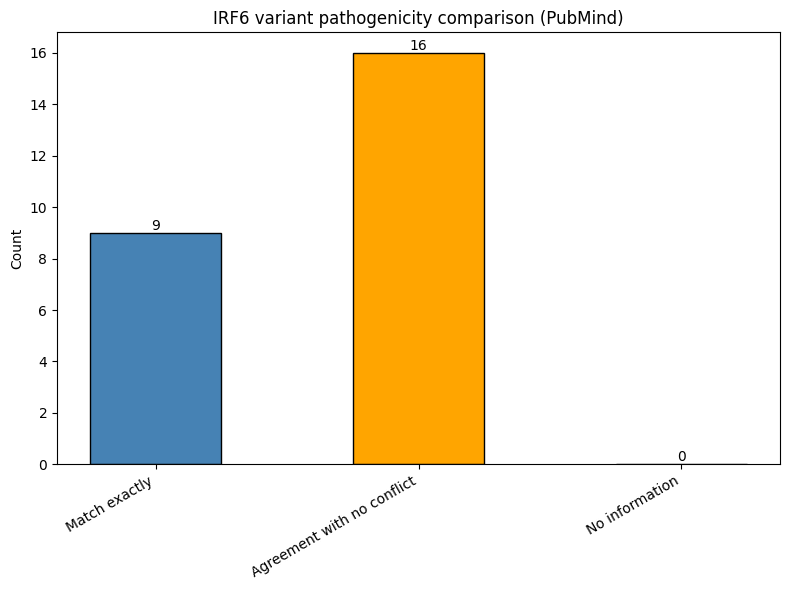

In [186]:
# Plot the result
fig, ax = plt.subplots(figsize=(8,6))
bars = ax.bar(
    df_counts['category'], 
    df_counts['count'], 
    width=0.5,                    
    color=['steelblue','orange','gray'], 
    edgecolor='black'
)

# Add numbers on top of bar
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontsize=10)

ax.set_ylabel("Count")
ax.set_title("IRF6 variant pathogenicity comparison (PubMind)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


As we can see, for all 16 records found by PubMind, they all agree with the ground truth and 9 of them match exacly in term of either pathogenic or benign.